# R32 — End-to-End Cascade BayesSearchCV for Referable Glaucoma

**Key difference from R31**: BayesSearchCV optimises **patient-level bilateral F1**
instead of per-eye F1. This means `pos_weight`, `alpha`, `lr`, `architecture`,
and `batch_size` are all tuned against the actual downstream metric.

Pipeline per encoder:
1. PCA → MI selection → metadata + OD masking (same as R28/R31)
2. **BayesSearchCV** with custom scorer: train MLP → per-eye proba → bilateral count → patient F1
3. 25-bag ensemble with best hyperparams
4. Isotonic calibration → bilateral threshold sweep on held-out val
5. Evaluate on test

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 1 — Imports
# ═══════════════════════════════════════════════════════════════════════
from __future__ import annotations
import json, time, warnings, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.collections import LineCollection

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, roc_curve,
    make_scorer,
)
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
from retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
print('R32 imports OK')

R32 imports OK


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 2 — Configuration
# ═══════════════════════════════════════════════════════════════════════

DATASET_NAME = 'brset'
TASK         = 'increased_cup_disc'   # per-eye label used by Stage 1
RANDOM_SEED  = 42

from multiprocessing import cpu_count
CPU_COUNT = cpu_count()

# ─── Paths ────────────────────────────────────────────────────────
BASE_DIR     = Path.cwd()
FE_DIR       = BASE_DIR / 'artifacts' / 'brset_eda_fe'
EMBED_DIR    = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH  = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'
RESULTS_DIR  = BASE_DIR / 'results' / 'brset_r32_e2e_cascade_referable_glaucoma'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# R28 dir (for comparison only)
R28_DIR = BASE_DIR / 'results' / 'brset_r28_fe_experiment' / 'r28_per_encoder'
R31_DIR = BASE_DIR / 'results' / 'brset_r31_cascade_referable_glaucoma' / 'r31_per_encoder'

# ─── Pipeline parameters (identical to R28/R31) ───────────────────
PCA_COMPONENTS       = 384
MI_SELECTION         = True
MI_PERCENTILE_THRESH = 0.15
MI_MIN_COMPONENTS    = 128

MLP_MAX_ITER   = 400
MLP_PATIENCE   = 30

BAG_SEEDS           = [42, 123, 314, 555, 789]
N_BAG_ARCH_VARIANTS = 5
N_BAGS = len(BAG_SEEDS) * N_BAG_ARCH_VARIANTS   # 25

THRESHOLD_GRID  = 301
THRESHOLD_FLOOR = 0.05

# ─── BayesSearchCV parameters ────────────────────────────────────
ARCHITECTURE_OPTIONS = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
    (128, 64), (384, 192),
    (384, 192, 96),
]

SEARCH_SPACE = {
    'hidden_layer_sizes': Categorical(list(range(len(ARCHITECTURE_OPTIONS)))),
    'alpha': Real(1e-3, 1.0, prior='log-uniform'),
    'learning_rate_init': Real(1e-4, 2e-3, prior='log-uniform'),
    'batch_size': Categorical([64, 128, 256]),
    'pos_class_weight': Real(1.0, 3.5, prior='uniform'),
}

BAYES_N_ITER   = 40
BAYES_CV_FOLDS = 3
BAYES_N_JOBS   = min(CPU_COUNT - 1, 6)

# ─── Clinical metadata (same 5 cols as R28) ──────────────────────
METADATA_COLS = {
    'age':      'numeric',
    'sex':      'passthrough',
    'diabetes': 'binary_yn',
    'exam_eye': 'binary',
    'camera':   'camera',
}

# ─── optic_disc masking (same as R28) ────────────────────────────
OD_P_MASK_BASE    = 0.50
OD_P_MASK_RANGE   = (0.35, 0.70)
OD_CORRUPT        = 0.10
OD_FEATURE_WEIGHT = 0.50
OD_MISS_WEIGHT    = 0.50
OD_TEST_P_MASK    = 0.25

# ─── Bilateral / referable threshold ─────────────────────────────
BILATERAL_MIN_EYES = 2

print(f'Results dir:     {RESULTS_DIR}')
print(f'Stage 1 task:    {TASK} (per-eye)')
print(f'Stage 2 rule:    ≥{BILATERAL_MIN_EYES} positive eyes → referable')
print(f'BayesSearchCV:   {BAYES_N_ITER} iters, {BAYES_CV_FOLDS}-fold CV')
print(f'  Search space:  arch={len(ARCHITECTURE_OPTIONS)} options, α=[1e-3,1], lr=[1e-4,2e-3], bs=[64/128/256], w=[1,3.5]')
print(f'Bagging: {len(BAG_SEEDS)} seeds × {N_BAG_ARCH_VARIANTS} variants = {N_BAGS}')
print(f'OD masking: base={OD_P_MASK_BASE:.0%}, range={OD_P_MASK_RANGE}, corrupt={OD_CORRUPT:.0%}')

Results dir:     c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r32_e2e_cascade_referable_glaucoma
Stage 1 task:    increased_cup_disc (per-eye)
Stage 2 rule:    ≥2 positive eyes → referable
BayesSearchCV:   40 iters, 3-fold CV
  Search space:  arch=11 options, α=[1e-3,1], lr=[1e-4,2e-3], bs=[64/128/256], w=[1,3.5]
Bagging: 5 seeds × 5 variants = 25
OD masking: base=50%, range=(0.35, 0.7), corrupt=10%


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 3 — Load Data + FE Artifacts
# ═══════════════════════════════════════════════════════════════════════

splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)

train_pids = set(splits[splits['split'] == 'train']['patient_id'])
val_pids   = set(splits[splits['split'] == 'val']['patient_id'])
test_pids  = set(splits[splits['split'] == 'test']['patient_id'])

assert len(train_pids & val_pids)  == 0
assert len(train_pids & test_pids) == 0
assert len(val_pids   & test_pids) == 0

labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))

def build_referable_labels(df, task_col, min_eyes):
    pos_count = df[df[task_col] == 1].groupby('patient_id')[task_col].count()
    all_pids = df['patient_id'].unique()
    result = pd.Series(0, index=all_pids, name='referable_glaucoma')
    referable = pos_count[pos_count >= min_eyes].index
    result.loc[result.index.isin(referable)] = 1
    return result

_preview_df = labels_raw.dropna(subset=[TASK]).copy()
_preview_df['patient_id'] = _preview_df['patient_id'].astype(str)
_ref = build_referable_labels(_preview_df, TASK, BILATERAL_MIN_EYES)
_ref_train = _ref[_ref.index.isin(train_pids)]
_ref_val   = _ref[_ref.index.isin(val_pids)]
_ref_test  = _ref[_ref.index.isin(test_pids)]

print(f'Patient split:   {len(train_pids)} train / {len(val_pids)} val / {len(test_pids)} test')
print(f'Embedding files: {len(embedding_files)}')
print(f'\nReferable glaucoma (≥{BILATERAL_MIN_EYES} eyes with {TASK}=1):')
print(f'  Train: {_ref_train.sum():>4}/{len(_ref_train)} ({_ref_train.mean():.1%})')
print(f'  Val:   {_ref_val.sum():>4}/{len(_ref_val)} ({_ref_val.mean():.1%})')
print(f'  Test:  {_ref_test.sum():>4}/{len(_ref_test)} ({_ref_test.mean():.1%})')

Patient split:   5796 train / 1023 val / 1705 test
Embedding files: 7

Referable glaucoma (≥2 eyes with increased_cup_disc=1):
  Train:  789/5796 (13.6%)
  Val:    157/1023 (15.3%)
  Test:   229/1705 (13.4%)


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 4 — Helper Functions
# ═══════════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128,
                       random_state=42):
    mi_scores = mutual_info_classif(
        X_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    X_train_sel = X_train[:, mask]
    X_others_sel = [X[:, mask] for X in X_others]
    return X_train_sel, X_others_sel, mask, mi_scores


def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


def make_wider(arch, factor=1.5):
    return tuple(max(64, int(x * factor)) for x in arch)
def make_deeper(arch):
    return arch + (max(64, arch[-1] // 2),)
def make_narrower(arch, factor=0.67):
    return tuple(max(64, int(x * factor)) for x in arch)
def make_shallower(arch):
    if len(arch) > 1: return arch[:-1]
    return (max(64, arch[0] // 2),)


def _bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2: return X_s
    if od_w != 1.0: X_s[:, -2] *= od_w
    if miss_w != 1.0: X_s[:, -1] *= miss_w
    return X_s


# ─── Bilateral cascade logic ──────────────────────────────────────
def bilateral_patient_predictions(pids, proba, threshold, min_eyes=2):
    df = pd.DataFrame({'patient_id': pids, 'proba': proba,
                        'pred_pos': (proba >= threshold).astype(int)})
    agg = df.groupby('patient_id').agg(
        n_positive=('pred_pos', 'sum'),
        n_images=('pred_pos', 'count'),
        max_proba=('proba', 'max'),
        mean_proba=('proba', 'mean'),
    )
    agg['referable_pred'] = (agg['n_positive'] >= min_eyes).astype(int)
    return agg


def sweep_bilateral_threshold(pids, proba, y_referable_patient,
                              min_eyes=2, grid_size=301, floor=0.05):
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    all_res = []
    for t in thresholds:
        agg = bilateral_patient_predictions(pids, proba, t, min_eyes)
        com = agg.index.intersection(y_referable_patient.index)
        if len(com) == 0: continue
        yt = y_referable_patient.loc[com].values
        yh = agg.loc[com, 'referable_pred'].values
        f1 = f1_score(yt, yh, zero_division=0) if yh.sum() > 0 else 0.0
        prec = precision_score(yt, yh, zero_division=0)
        rec  = recall_score(yt, yh, zero_division=0)
        all_res.append({'threshold': t, 'f1': f1, 'precision': prec, 'recall': rec,
                        'n_predicted_pos': int(yh.sum())})
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1, pd.DataFrame(all_res)


# ─── MLPWrapper with bilateral cascade scoring ────────────────────
class MLPCascadeWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps MLPClassifier for BayesSearchCV.
    The key innovation: when used with our custom bilateral_cascade_scorer,
    the scorer will:
      1. Get per-image probabilities from this estimator
      2. Map images → patients using _pids attached to X
      3. Apply bilateral counting (≥ min_eyes positive → referable)
      4. Compute patient-level F1
    """
    def __init__(self, hidden_layer_sizes=0, alpha=0.01,
                 learning_rate_init=0.001, batch_size=64,
                 pos_class_weight=1.0, max_iter=400,
                 early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=30, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self._mlp = None

    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes

    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate='adaptive',
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size, max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
        )
        sw = make_sample_weights(y, pos_class_weight=self.pos_class_weight)
        self._mlp.fit(X, y, sample_weight=sw)
        self.classes_ = self._mlp.classes_
        return self

    def predict(self, X): return self._mlp.predict(X)
    def predict_proba(self, X): return self._mlp.predict_proba(X)


def make_bilateral_cascade_scorer(pids_array, y_eye, min_eyes=2,
                                  grid_size=51, floor=0.10):
    """
    Returns a sklearn scorer that evaluates patient-level bilateral F1.
    
    Strategy: the scorer receives the CV fold's validation indices.
    It uses pids_array[indices] to get patient IDs, builds per-patient
    referable ground truth from y_eye[indices], then does a quick
    bilateral threshold sweep on the per-image probabilities.
    """
    def _bilateral_f1_scorer(estimator, X, y_unused, **kwargs):
        # y_unused is the per-eye label passed by CV, but we want patient-level
        # Get the indices of this fold's validation samples
        # X is the sliced array, but we need to find corresponding pids.
        # We stored pids alongside, so we pass them via the _fold_pids trick.
        # BUT sklearn scorers don't pass indices...
        # WORKAROUND: We compute per-eye proba and use the fact that
        # y_unused == y_eye[fold_indices] to reverse-lookup the indices.
        #
        # Actually, simpler approach: use the sample indices passed via kwargs
        # or reconstruct from X shape. But sklearn doesn't pass indices to scorers.
        #
        # CLEANEST APPROACH: Embed patient_id as last column of X.
        # The estimator ignores it (we strip it in fit/predict), but the
        # scorer can read it.
        
        # Extract patient IDs from last column
        fold_pids = X[:, -1].astype(int).astype(str)
        
        # Pass full X — the wrapper strips the pid column internally
        proba = estimator.predict_proba(X)[:, 1]
        
        # Build referable ground truth for this fold's patients
        fold_eye_labels = y_unused  # per-eye labels
        ref_gt = build_referable_labels(
            pd.DataFrame({'patient_id': fold_pids, TASK: fold_eye_labels}),
            TASK, min_eyes
        )
        
        # Quick bilateral threshold sweep
        thresholds = np.linspace(floor, 0.95, grid_size)
        best_f1 = 0.0
        for t in thresholds:
            agg = bilateral_patient_predictions(fold_pids, proba, t, min_eyes)
            com = agg.index.intersection(ref_gt.index)
            if len(com) == 0: continue
            yt = ref_gt.loc[com].values
            yh = agg.loc[com, 'referable_pred'].values
            if yh.sum() == 0: continue
            f1 = f1_score(yt, yh, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
        return best_f1
    
    return _bilateral_f1_scorer


class MLPCascadeWrapperWithPids(MLPCascadeWrapper):
    """
    Same as MLPCascadeWrapper but strips the last column (patient_id)
    before passing to the MLP. This lets us embed pids in X for the
    scorer to read while keeping the MLP unaware.
    """
    def fit(self, X, y, sample_weight=None):
        return super().fit(X[:, :-1], y, sample_weight)
    
    def predict(self, X):
        return super().predict(X[:, :-1])
    
    def predict_proba(self, X):
        return super().predict_proba(X[:, :-1])


# ─── Plotting ─────────────────────────────────────────────────────
def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    cm_plot = np.ma.masked_where(cm <= 0, cm)
    vmax = int(cm.max()) if cm.size else 1
    norm = LogNorm(vmin=1, vmax=max(1, vmax))
    im = ax.imshow(cm_plot, cmap='viridis', interpolation='nearest', norm=norm)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Count (log)', fontsize=9)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


def plot_roc_curve(fpr, tpr, auc_val, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=Normalize(0, 1))
    lc.set_array(fpr); lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0,1],[0,1],'--', color='#666', lw=1.2, label='Chance')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f'{title}\nAUC = {auc_val:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04).set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


print(f'Helpers OK  (bilateral min eyes = {BILATERAL_MIN_EYES})')

Helpers OK  (bilateral min eyes = 2)


## Per-Encoder Loop: BayesSearchCV → Bagging → Bilateral Evaluation

For each encoder:
1. PCA + MI selection + metadata + OD masking (same as R28/R31)
2. **BayesSearchCV** (40 iter, 3-fold, per-encoder random seed) with **bilateral cascade F1** as scoring
3. Extract best `(arch, alpha, lr, batch_size, pos_weight)`
4. 25-bag ensemble with best hyperparams
5. Isotonic calibration → bilateral threshold sweep on val
6. Test evaluation + save artifacts

**R32b fixes** (vs R32a):
- Per-encoder `random_state = RANDOM_SEED + emb_idx` → each encoder explores unique search space
- 40 iterations (30 Bayesian-guided after 10 random initial points)
- 3-fold patient-stratified CV
- `pos_class_weight` capped at 3.5 (was 5.0)
- Scorer grid_size = 31 (was 21)

════════════════════════════════════════════════════════════════════════════════
R32 — End-to-End Cascade BayesSearchCV: Bilateral F1 as Objective
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
[1/7] R32 — convnextv2_base_
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 40 iters, 3-fold patient-stratified CV
    Scoring: bilateral cascade F1 (per trial: MLP → per-eye proba → ≥2 eyes → patient F1)
  ★ Best CV bilateral F1: 0.6643
    arch=(512,)  α=1.0000  lr=0.000100  bs=256  w=2.532
  [Bagging] 25 models
  Stage C done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  ★ Stage D: calibrated | bilateral_thr=0.222 | val_F1=0.7922
  TEST: F1=0.7521  Prec=0.7247  Rec=0.7817  AUC=0.9448  BalAcc=0.8678
  Val−Test ga

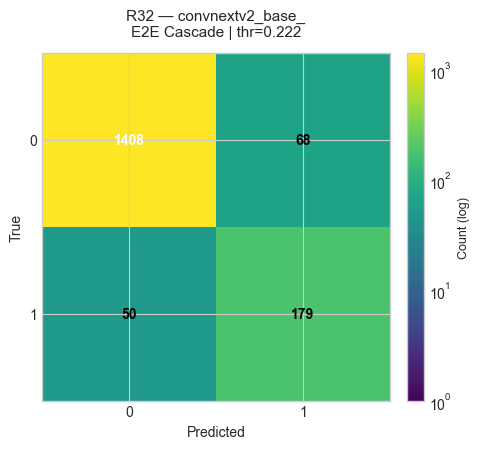

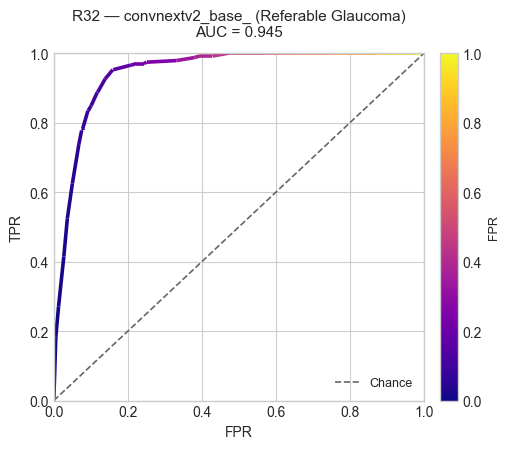


════════════════════════════════════════════════════════════════════════════════
[2/7] R32 — dinov3_convnext_base
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 40 iters, 3-fold patient-stratified CV
    Scoring: bilateral cascade F1 (per trial: MLP → per-eye proba → ≥2 eyes → patient F1)
  ★ Best CV bilateral F1: 0.6284
    arch=(512,)  α=1.0000  lr=0.000100  bs=64  w=3.500
  [Bagging] 25 models
  Stage C done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  ★ Stage D: raw | bilateral_thr=0.495 | val_F1=0.7893
  TEST: F1=0.7523  Prec=0.7767  Rec=0.7293  AUC=0.9476  BalAcc=0.8484
  Val−Test gap: +0.0370
  Time: 5972s (99.5 min)
               precision    recall  f1-score   support

Not Referable      0.958     0.967     0.963      1476
    Referable      0.777     0.729     0.752       229

     accuracy                

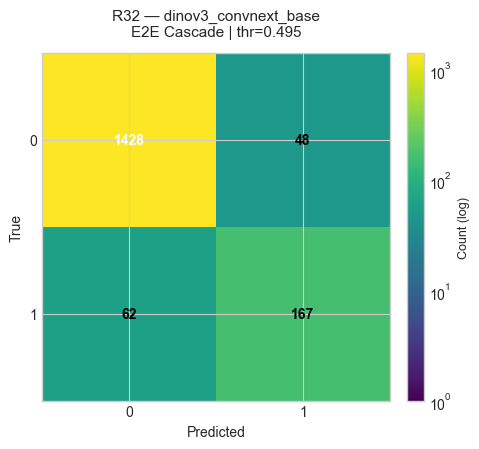

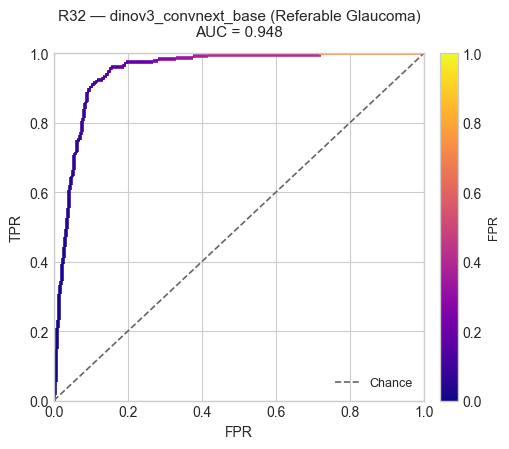


════════════════════════════════════════════════════════════════════════════════
[3/7] R32 — dinov3_vitb16
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.7% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 40 iters, 3-fold patient-stratified CV
    Scoring: bilateral cascade F1 (per trial: MLP → per-eye proba → ≥2 eyes → patient F1)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 5 — Per-Encoder Loop with End-to-End BayesSearchCV
# ═══════════════════════════════════════════════════════════════════════

R32_DIR = RESULTS_DIR / 'r32_per_encoder'
R32_DIR.mkdir(parents=True, exist_ok=True)

print('═' * 80)
print('R32 — End-to-End Cascade BayesSearchCV: Bilateral F1 as Objective')
print('═' * 80)

r32_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint: skip if results already exist ──────────────────
    chk_dir = R32_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED, loading')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r32_results.append({
            'embedding': sname,
            'dim_raw': prev.get('emb_dim_raw', 0),
            'dim_pca': prev['pca_dim'],
            'dim_mi': prev['mi_selected'],
            'pca_var': prev['pca_var'],
            'r32_arch': prev['r32_architecture'],
            'r32_alpha': prev['r32_alpha'],
            'r32_lr': prev['r32_lr'],
            'r32_pos_weight': prev['r32_pos_weight'],
            'r32_batch_size': prev['r32_batch_size'],
            'bayes_cv_f1': prev['bayes_cv_f1'],
            'bilateral_threshold': prev['bilateral_threshold'],
            'val_referable_f1': prev['val_referable_f1'],
            'test_referable_f1': prev['test_referable_f1'],
            'test_referable_precision': prev['test_referable_precision'],
            'test_referable_recall': prev['test_referable_recall'],
            'test_referable_auc': prev['test_referable_auc'],
            'test_referable_bal_acc': prev['test_referable_bal_acc'],
            'n_test_patients': prev['n_test_patients'],
            'time_s': 0,
        })
        continue

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R32 — {sname}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE A: Feature preparation (same as R28/R31)
    # ══════════════════════════════════════════════════════════════

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # PCA
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # MI Selection
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # Metadata
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    # OD masking
    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    # Scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # Val/test with P25 OD masking
    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ══════════════════════════════════════════════════════════════
    # STAGE B: BayesSearchCV with Bilateral Cascade F1 Scoring
    # ══════════════════════════════════════════════════════════════

    # Embed patient_id as last column so the scorer can read it
    pid_col_tr = np.array([int(p) for p in pids_tr], dtype=np.float64).reshape(-1, 1)
    X_tr_s_with_pids = np.hstack([X_tr_s, pid_col_tr])

    # Create the custom scorer
    bilateral_scorer = make_bilateral_cascade_scorer(
        pids_tr, yb_train, min_eyes=BILATERAL_MIN_EYES,
        grid_size=31, floor=0.10,
    )

    # Patient-stratified CV: split by patient, not by image
    # We need custom CV that respects patient grouping
    unique_train_pids = np.unique(pids_tr)
    pid_ref_labels = build_referable_labels(b_train, TASK, BILATERAL_MIN_EYES)
    pid_labels_for_cv = np.array([pid_ref_labels.get(p, 0) for p in unique_train_pids])

    # Map images to their patient's position in unique_train_pids
    pid_to_idx = {p: i for i, p in enumerate(unique_train_pids)}
    image_pid_indices = np.array([pid_to_idx[p] for p in pids_tr])

    # Generate patient-level CV folds, then expand to image-level indices
    skf = StratifiedKFold(n_splits=BAYES_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    patient_cv_folds = list(skf.split(unique_train_pids, pid_labels_for_cv))

    image_cv_folds = []
    for pat_train_idx, pat_val_idx in patient_cv_folds:
        train_pids_fold = set(unique_train_pids[pat_train_idx])
        val_pids_fold   = set(unique_train_pids[pat_val_idx])
        img_train_idx = np.where(np.isin(pids_tr, list(train_pids_fold)))[0]
        img_val_idx   = np.where(np.isin(pids_tr, list(val_pids_fold)))[0]
        image_cv_folds.append((img_train_idx, img_val_idx))

    print(f'  [BayesSearchCV] {BAYES_N_ITER} iters, {BAYES_CV_FOLDS}-fold patient-stratified CV')
    print(f'    Scoring: bilateral cascade F1 (per trial: MLP → per-eye proba → ≥{BILATERAL_MIN_EYES} eyes → patient F1)')

    # Per-encoder random state so each encoder explores different
    # initial random points instead of sharing the first 10 trials
    encoder_seed = RANDOM_SEED + emb_idx

    base_model = MLPCascadeWrapperWithPids(
        max_iter=MLP_MAX_ITER, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
        random_state=encoder_seed,
    )

    bayes = BayesSearchCV(
        estimator=base_model,
        search_spaces=SEARCH_SPACE,
        n_iter=BAYES_N_ITER,
        cv=image_cv_folds,
        n_jobs=1,  # scorer uses numpy arrays, avoid pickle issues
        scoring=bilateral_scorer,
        random_state=encoder_seed,
        verbose=0,
    )

    bayes.fit(X_tr_s_with_pids, yb_train)

    bp = bayes.best_params_
    bcv_f1 = bayes.best_score_
    ai = bp.get('hidden_layer_sizes', 0)
    barch = ARCHITECTURE_OPTIONS[ai] if isinstance(ai, int) else ai
    balpha = bp['alpha']
    blr    = bp['learning_rate_init']
    bbs    = bp['batch_size']
    bw     = bp['pos_class_weight']

    print(f'  ★ Best CV bilateral F1: {bcv_f1:.4f}')
    print(f'    arch={barch}  α={balpha:.4f}  lr={blr:.6f}  bs={bbs}  w={bw:.3f}')

    # ══════════════════════════════════════════════════════════════
    # STAGE C: 25-Bag Ensemble with Best Params
    # ══════════════════════════════════════════════════════════════

    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Bagging] {N_BAGS} models')

    cal_p = {}
    cal_l = {}
    bag_va_proba = []
    bag_te_proba = []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive',
                learning_rate_init=blr, batch_size=bbs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage C done: {N_BAGS} MLPs trained')
    print(f'  Per-image proba range: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE D: Bilateral Threshold Sweep on Val → Test
    # ══════════════════════════════════════════════════════════════

    ref_val  = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    best_overall_f1 = 0.0
    best_overall_t  = 0.5
    best_pt = 'calibrated'

    for pt_name, va_proba, te_proba in [
        ('calibrated', avg_va_cal, avg_te_cal),
        ('raw', avg_va_raw, avg_te_raw),
    ]:
        bt, bf1, sweep_df = sweep_bilateral_threshold(
            pids_va, va_proba, ref_val,
            min_eyes=BILATERAL_MIN_EYES,
            grid_size=THRESHOLD_GRID,
            floor=THRESHOLD_FLOOR,
        )
        if bf1 > best_overall_f1:
            best_overall_f1 = bf1
            best_overall_t  = bt
            best_pt = pt_name

    print(f'  ★ Stage D: {best_pt} | bilateral_thr={best_overall_t:.3f} | val_F1={best_overall_f1:.4f}')

    # ── Evaluate on TEST ──────────────────────────────────────────
    te_proba_use = avg_te_cal if best_pt == 'calibrated' else avg_te_raw
    va_proba_use = avg_va_cal if best_pt == 'calibrated' else avg_va_raw

    test_agg = bilateral_patient_predictions(pids_te, te_proba_use, best_overall_t, BILATERAL_MIN_EYES)
    com = test_agg.index.intersection(ref_test.index)
    yt = ref_test.loc[com].values
    yh = test_agg.loc[com, 'referable_pred'].values
    yp = test_agg.loc[com, 'max_proba'].values

    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))

    elapsed = time.time() - t0

    print(f'  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Val−Test gap: {best_overall_f1 - test_f1:+.4f}')
    print(f'  Time: {elapsed:.0f}s ({elapsed/60:.1f} min)')

    # ── Save artifacts ────────────────────────────────────────────
    out_dir = R32_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    pd.DataFrame({
        'patient_id': com,
        'y_true_referable': yt,
        'y_pred_referable': yh,
        'max_proba': yp,
        'n_positive_eyes': test_agg.loc[com, 'n_positive'].values,
        'n_images': test_agg.loc[com, 'n_images'].values,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    pd.DataFrame({
        'image_id': b_test['image_id'].values,
        'patient_id': pids_te,
        'y_true_eye': yb_test,
        'proba_calibrated': avg_te_cal,
        'proba_raw': avg_te_raw,
        'pred_positive_eye': (te_proba_use >= best_overall_t).astype(int),
    }).to_csv(out_dir / 'image_predictions.csv', index=False)

    _, _, sweep_final = sweep_bilateral_threshold(
        pids_va, va_proba_use, ref_val,
        min_eyes=BILATERAL_MIN_EYES, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR)
    sweep_final.to_csv(out_dir / 'bilateral_threshold_sweep.csv', index=False)

    hp_save = {
        'track': 'R32', 'embedding': sname,
        'r32_architecture': str(barch), 'r32_alpha': float(balpha),
        'r32_lr': float(blr), 'r32_batch_size': int(bbs),
        'r32_pos_weight': float(bw),
        'bayes_cv_f1': float(bcv_f1),
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'emb_dim_raw': emb_dim_raw, 'ndim': ndim,
        'n_bags': N_BAGS,
        'bilateral_min_eyes': BILATERAL_MIN_EYES,
        'bilateral_threshold': float(best_overall_t),
        'proba_type': best_pt,
        'val_referable_f1': float(best_overall_f1),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(com)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R32 — {sname}\nE2E Cascade | thr={best_overall_t:.3f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R32 — {sname} (Referable Glaucoma)',
        save_path=out_dir / 'roc_curve.png', show=True)

    r32_results.append({
        'embedding': sname,
        'dim_raw': emb_dim_raw, 'dim_pca': nc, 'dim_mi': int(n_kept),
        'pca_var': float(var_exp),
        'r32_arch': str(barch), 'r32_alpha': float(balpha),
        'r32_lr': float(blr), 'r32_pos_weight': float(bw),
        'r32_batch_size': int(bbs),
        'bayes_cv_f1': float(bcv_f1),
        'bilateral_threshold': float(best_overall_t),
        'val_referable_f1': float(best_overall_f1),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(com)),
        'time_s': float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R32 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

r32_df = pd.DataFrame(r32_results).sort_values('test_referable_f1', ascending=False)
r32_df.to_csv(R32_DIR / 'r32_summary.csv', index=False)

print('\n── R32 Per-Encoder Summary (sorted by Test Referable F1) ──')
show_cols = ['embedding', 'bayes_cv_f1', 'val_referable_f1', 'test_referable_f1',
             'test_referable_precision', 'test_referable_recall',
             'test_referable_auc', 'bilateral_threshold',
             'r32_pos_weight', 'r32_arch']
print(r32_df[[c for c in show_cols if c in r32_df.columns]].to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 6 — R32 vs R31 vs R29 Comparison
# ═══════════════════════════════════════════════════════════════════════

print('═' * 80)
print('R32 vs R31 vs R29 — Referable Glaucoma Comparison')
print('═' * 80)

# Load R31 summary
r31_path = R31_DIR / 'r31_summary.csv'
r31_loaded = pd.read_csv(r31_path) if r31_path.exists() else pd.DataFrame()

# Load R29 summary
r29_path = BASE_DIR / 'results' / 'brset_r29_referable_glaucoma' / 'r29_per_encoder' / 'r29_summary.csv'
r29_loaded = pd.read_csv(r29_path) if r29_path.exists() else pd.DataFrame()

comparison_rows = []
for _, row in r32_df.iterrows():
    enc = row['embedding']
    comp = {'embedding': enc,
            'R32_f1': row['test_referable_f1'],
            'R32_prec': row['test_referable_precision'],
            'R32_rec': row['test_referable_recall'],
            'R32_auc': row['test_referable_auc'],
            'R32_pos_w': row['r32_pos_weight']}

    # R31
    if not r31_loaded.empty:
        m31 = r31_loaded[r31_loaded['embedding'] == enc]
        if not m31.empty:
            comp['R31_f1']  = m31.iloc[0]['test_referable_f1']
            comp['R31_pos_w'] = m31.iloc[0].get('r28_pos_weight', np.nan)

    # R29
    if not r29_loaded.empty:
        # Find f1 column
        for fc in ['test_f1', 'f1_P25', 'f1']:
            if fc in r29_loaded.columns:
                m29 = r29_loaded[r29_loaded['embedding'] == enc]
                if not m29.empty:
                    comp['R29_f1'] = m29.iloc[0][fc]
                break

    comparison_rows.append(comp)

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

# Summary
best_r32 = r32_df['test_referable_f1'].max()
best_r32_enc = r32_df.loc[r32_df['test_referable_f1'].idxmax(), 'embedding']

print(f'\n── Best F1 per track ──')
print(f'  R32 (E2E cascade): {best_r32:.4f}  ({best_r32_enc})')
if not r31_loaded.empty:
    best_r31 = r31_loaded['test_referable_f1'].max()
    best_r31_enc = r31_loaded.loc[r31_loaded['test_referable_f1'].idxmax(), 'embedding']
    print(f'  R31 (cascade):     {best_r31:.4f}  ({best_r31_enc})')
    print(f'  R32 vs R31 delta: {best_r32 - best_r31:+.4f}')

# How many encoders meet 0.80?
n_above = (r32_df['test_referable_f1'] >= 0.80).sum()
print(f'\n  Encoders meeting F1 ≥ 0.80 target: {n_above}/{len(r32_df)}')
if n_above > 0:
    above = r32_df[r32_df['test_referable_f1'] >= 0.80]
    for _, r in above.iterrows():
        print(f'    ✓ {r["embedding"]}: F1={r["test_referable_f1"]:.4f}')

════════════════════════════════════════════════════════════════════════════════
R32 vs R31 vs R29 — Referable Glaucoma Comparison
════════════════════════════════════════════════════════════════════════════════
               embedding   R32_f1  R32_prec  R32_rec  R32_auc  R32_pos_w   R31_f1  R31_pos_w   R29_f1
           dinov3_vitb16 0.804301  0.792373 0.816594 0.947918   2.524259 0.800885   2.448675 0.721382
RETFound_dinov2_shanghai 0.782979  0.763485 0.803493 0.942104   2.524259 0.743494   2.908782 0.642241
        convnextv2_base_ 0.771855  0.754167 0.790393 0.947119   1.603808 0.744467   4.070851 0.698413
               vit_base_ 0.742358  0.742358 0.742358 0.934042   4.615408 0.699248   2.620812 0.661844
    dinov3_convnext_base 0.737089  0.796954 0.685590 0.942817   4.615408 0.764045   2.462905 0.687161
   RETFound_mae_shanghai 0.709677  0.751220 0.672489 0.937091   1.000000 0.728538   1.000000 0.642398
  RETFound_mae_natureCFP 0.692841  0.735294 0.655022 0.926569   4.344745 0